<a href="https://colab.research.google.com/github/j5675293/DESAFIOS__NPL_1/blob/NPL_1/DESAFIO_3_NLP_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO 3
## CARRERA DE ESPECIALIDAD EN INTELIGENCIA ARTIFICIAL - FIUBA
### JUAN RUIZ OTONDO
#### a1702

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.
### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [1]:
import random
import io
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [3]:
raw_html = urllib.request.urlopen('https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook') # dataset para entrenamiento
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag )
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '

# pasar todo el texto a minúscula
article_text = article_text.lower()

In [4]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' en el año 1872, la casa número 7 de saville-row, burlington gardens \r\n—donde murió sheridan en 1814— estaba habitada por phileas fogg, quien a\r\n pesar de que parecía haber tomado el partido de no hacer nada que \r\npudiese llamar la atención, era uno de los miembros más notables y \r\nsingulares del reformclub de londres. por consiguiente, phileas fogg, personaje enigmático y del cual sólo \r\nse sabía que era un hombre muy galante y de los más cumplidos gentlemen \r\nde la alta sociedad inglesa, sucedía a uno de los más grandes oradores \r\nque honran a inglaterra. decíase que se daba un aire a lo byron —su cabeza, se entiende, \r\nporque, en cuanto a los pies, no tenía defecto alguno—, pero a un byron \r\nde bigote y pastillas, a un byron impasible, que hubiera vivido mil años\r\n sin envejecer. phileas fogg, era inglés de pura cepa; pero quizás no había nacido en\r\n londres. jamás se le había visto en la bolsa ni en el banco, ni en \r\nninguno de los despachos mercantiles de 

In [5]:
#  Instalación dependencias
!pip install beautifulsoup4


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import urllib.request
import re
from collections import Counter
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

In [81]:
print("=" * 60)
print("🚀 INICIANDO MODELO DE LENGUAJE CON RNNS")
print("=" * 60)
print(f"📊 TensorFlow version: {tf.__version__}")
#print(f"🐍 Python version: {sys.version.split()[0]}")
print("=" * 60)

🚀 INICIANDO MODELO DE LENGUAJE CON RNNS
📊 TensorFlow version: 2.18.0


In [ ]:
#np.random.seed(42)
#tf.random.set_seed(42)

print("✅ Configuración completada")

✅ Configuración completada


In [8]:
# ============================================================================
# PASO 1: DESCARGA Y PROCESAMIENTO DEL TEXTO
# ============================================================================
print("\n" + "="*50)
print("DESCARGANDO TEXTO...")
print("="*50)


DESCARGANDO TEXTO...


In [9]:
def descargar_y_procesar_texto():
    url = 'https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook'

    try:
        print(f"Descargando desde: {url}")

        # El código inicial generado
        raw_html = urllib.request.urlopen(url)
        raw_html = raw_html.read()

        print("✅ Descarga exitosa")
        print(f"Tamaño del HTML: {len(raw_html)} bytes")

        # Procesa HTML
        soup = BeautifulSoup(raw_html, 'html.parser')
        texto = soup.get_text()

        print(f"Texto extraído: {len(texto)} caracteres")

        # Limpia texto
        texto = re.sub(r'\n+', ' ', texto)
        texto = re.sub(r'\s+', ' ', texto)
        texto = re.sub(r'[^\w\s.,;:!?¿¡\-áéíóúüñÁÉÍÓÚÜÑ]', '', texto)
        texto = texto.lower().strip()

        # Toma una porción manejable
        if len(texto) > 50000:
            texto = texto[:50000]

        print(f"Texto procesado: {len(texto)} caracteres")
        print(f"Muestra: {texto[:200]}...")

        return texto

    except Exception as e:
        print(f"❌ Error: {e}")
        print("Usando texto de prueba...")

        texto_prueba = """
        phileas fogg era uno de esos hombres matemáticamente exactos que nunca se apresuran.
        no daba un paso inútil y seguía siempre el camino más corto. era el hombre menos apresurado
        del mundo pero llegaba siempre a tiempo. jean passepartout era un verdadero parisino de parís.
        había servido como ayuda de cámara en varias casas. su último amo resultó caprichoso e irregular.
        passepartout deseaba poder respetar a su amo. al enterarse de que phileas fogg buscaba un criado
        se presentó al caballero. conocía la vida metódica del personaje. aquel género de vida le convenía.
        """ * 20  # Se podria repetir para tener más contenido

        return texto_prueba.strip()

# Se ejecuta descarga y se tiene el corpus
texto_corpus = descargar_y_procesar_texto()
print(f"\n✅ Corpus listo: {len(texto_corpus)} caracteres")

Descargando desde: https://www.textos.info/julio-verne/la-vuelta-al-mundo-en-80-dias/ebook
✅ Descarga exitosa
Tamaño del HTML: 467598 bytes
Texto extraído: 401394 caracteres
Texto procesado: 50000 caracteres
Muestra: la vuelta al mundo en 80 días  julio verne - textos.info navegación textos.info biblioteca buscar libros textos títulos autores etiquetas editores publicar regalar acceso registro inicio julio verne l...

✅ Corpus listo: 50000 caracteres


In [10]:
# ============================================================================
# PASO 2: CREA VOCABULARIO
# ============================================================================
print("\n" + "="*50)
print("CREANDO VOCABULARIO...")
print("="*50)


CREANDO VOCABULARIO...


In [11]:
# Se tokeniza
palabras = texto_corpus.split()
print(f"Total de palabras: {len(palabras)}")

# Se cuenta frecuencias
contador_palabras = Counter(palabras)
palabras_unicas = len(contador_palabras)
print(f"Palabras únicas: {palabras_unicas}")

Total de palabras: 8434
Palabras únicas: 2946


In [12]:
from collections import Counter

# Texto de ejemplo
texto = "La vuelta al mundo en 80 días es una novela de Julio Verne."

# Tokenización simple
palabras = texto.lower().split()

# Se cuenta frecuencia de palabras
contador = Counter(palabras)

# Se convierte  lista de tuplas ordenadas por frecuencia
palabras_frecuentes = sorted(contador.items(), key=lambda x: x[1], reverse=True)


In [13]:
# Mapeos
word_to_idx = {'<PAD>': 0, '<UNK>': 1, '<START>': 2}
idx_to_word = {0: '<PAD>', 1: '<UNK>', 2: '<START>'}

for i, (palabra, freq) in enumerate(palabras_frecuentes):
    idx = i + 3
    word_to_idx[palabra] = idx
    idx_to_word[idx] = palabra

print(f"Vocabulario final: {len(word_to_idx)} palabras")
print("Palabras más frecuentes:")
for palabra, freq in palabras_frecuentes[:10]:
    print(f"  '{palabra}': {freq}")


Vocabulario final: 16 palabras
Palabras más frecuentes:
  'la': 1
  'vuelta': 1
  'al': 1
  'mundo': 1
  'en': 1
  '80': 1
  'días': 1
  'es': 1
  'una': 1
  'novela': 1


In [14]:
# ============================================================================
# PASO 3: CREA DATOS DE ENTRENAMIENTO
# ============================================================================
print("\n" + "="*50)
print("CREANDO DATOS DE ENTRENAMIENTO...")
print("="*50)


CREANDO DATOS DE ENTRENAMIENTO...


In [15]:
SEQUENCE_LENGTH = 30

# Se convierte texto a índices
def texto_a_indices(texto):
    palabras = texto.split()
    indices = []
    for palabra in palabras:
        if palabra in word_to_idx:
            indices.append(word_to_idx[palabra])
        else:
            indices.append(word_to_idx['<UNK>'])
    return indices

indices_texto = texto_a_indices(texto_corpus)
print(f"Secuencia de índices: {len(indices_texto)}")

Secuencia de índices: 8434


In [16]:
# Se crea secuencias X e y
X_data = []
y_data = []

for i in range(len(indices_texto) - SEQUENCE_LENGTH):
    X_data.append(indices_texto[i:i + SEQUENCE_LENGTH])
    y_data.append(indices_texto[i + SEQUENCE_LENGTH])

X_data = np.array(X_data)
y_data = np.array(y_data)

print(f"Forma de X: {X_data.shape}")
print(f"Forma de y: {y_data.shape}")

Forma de X: (8404, 30)
Forma de y: (8404,)


In [17]:
# Se dividi entrenamiento/validación
split_idx = int(len(X_data) * 0.8)
X_train = X_data[:split_idx]
X_val = X_data[split_idx:]
y_train = y_data[:split_idx]
y_val = y_data[split_idx:]

In [18]:
# Se convierte y a categorica
y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(word_to_idx))
y_val_cat = keras.utils.to_categorical(y_val, num_classes=len(word_to_idx))

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_train: {y_train_cat.shape}")
print(f"y_val: {y_val_cat.shape}")

X_train: (6723, 30)
X_val: (1681, 30)
y_train: (6723, 16)
y_val: (1681, 16)


In [19]:
# ============================================================================
# PASO 4: CREA Y ENTRENA MODELO LSTM
# ============================================================================
print("\n" + "="*50)
print("CREANDO MODELO LSTM...")
print("="*50)


CREANDO MODELO LSTM...


In [21]:
from tensorflow.keras.callbacks import EarlyStopping

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [23]:
modelo = keras.Sequential([
    layers.Embedding(input_dim=len(word_to_idx), output_dim=128, input_length=SEQUENCE_LENGTH),
    layers.Bidirectional(layers.LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    layers.LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(word_to_idx), activation='softmax')
])

In [24]:
print("Arquitectura del modelo:")

modelo.build(input_shape=(None, SEQUENCE_LENGTH))
modelo.summary()

Arquitectura del modelo:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         2,064 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,776 (1.36 MB)

 Trainable params: 357,776 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Interpretación
- Con 357,776 parámetros, no es un modelo excesivamente grande, pero es lo suficientemente complejo para una tarea de clasificación de secuencias.
- El tamaño del vocabulario de 16 palabras es la característica más llamativa y potencialmente limitante.
- El modelo tiene una arquitectura sólida para PLN, pero su capacidad real estará severamente limitada por el minúsculo tamaño del vocabulario de 16 palabras. Es una debilidad para el modelo.

In [25]:
# ============================================================================
# PASO 5: ENTRENAR MODELO
# ============================================================================
print("\n" + "="*50)
print("ENTRENANDO MODELO...")
print("="*50)


ENTRENANDO MODELO...


In [27]:
# Callback para perplejidad
class CallbackPerplejidad(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss', 0)
        perplejidad = np.exp(val_loss)
        print(f"Época {epoch+1} - Perplejidad: {perplejidad:.2f}")

# COMPILA EL MODELO
modelo.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # Asumiendo clasificación multiclase
    metrics=['accuracy']
)

# Entrena
print("Iniciando entrenamiento...")
historia = modelo.fit(
    X_train, y_train_cat,
    batch_size=32,
    epochs=25,
    validation_data=(X_val, y_val_cat),
    callbacks=[CallbackPerplejidad()],
    verbose=1
)
print("✅ Entrenamiento completado")

Iniciando entrenamiento...
Epoch 1/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8417 - loss: 0.9098Época 1 - Perplejidad: 1.78
211/211 ━━━━━━━━━━━━━━━━━━━━ 57s 213ms/step - accuracy: 0.8418 - loss: 0.9086 - val_accuracy: 0.8715 - val_loss: 0.5758
Epoch 2/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8723 - loss: 0.5993Época 2 - Perplejidad: 1.77
211/211 ━━━━━━━━━━━━━━━━━━━━ 82s 214ms/step - accuracy: 0.8723 - loss: 0.5992 - val_accuracy: 0.8715 - val_loss: 0.5723
Epoch 3/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8703 - loss: 0.5976Época 3 - Perplejidad: 1.76
211/211 ━━━━━━━━━━━━━━━━━━━━ 81s 210ms/step - accuracy: 0.8704 - loss: 0.5975 - val_accuracy: 0.8715 - val_loss: 0.5641
Epoch 4/25
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.8786 - loss: 0.5531Época 4 - Perplejidad: 1.76
211/211 ━━━━━━━━━━━━━━━━━━━━ 45s 211ms/step - accuracy: 0.8785 - loss: 0.5532 - val_accuracy: 0.8715 - val_loss: 0.5670
Epoch 5/25
211/211 ━━━━━━━━━━━━━━

### Interpretación
- Accuracy; Esta es la precisión del modelo sobre el conjunto de entrenamiento al final de esta época. Significa que el modelo clasificó correctamente el 87.66% de los ejemplos en el conjunto de entrenamiento.
- Loss (0.55); Esta es la pérdida del modelo sobre el conjunto de entrenamiento al final de esta época. La pérdida es una medida de qué tan bien se está desempeñando el modelo; un valor más bajo indica un mejor rendimiento.
- Una perplejidad más baja significa que el modelo está más seguro y hace mejores predicciones. Una perplejidad de 1.73 es un buen valor, especialmente si el vocabulario no es excesivamente grande.

In [28]:
# ============================================================================
# PASO 6: VISUALIZA ENTRENAMIENTO
# ============================================================================
print("\n" + "="*50)
print("VISUALIZANDO RESULTADOS...")
print("="*50)


VISUALIZANDO RESULTADOS...


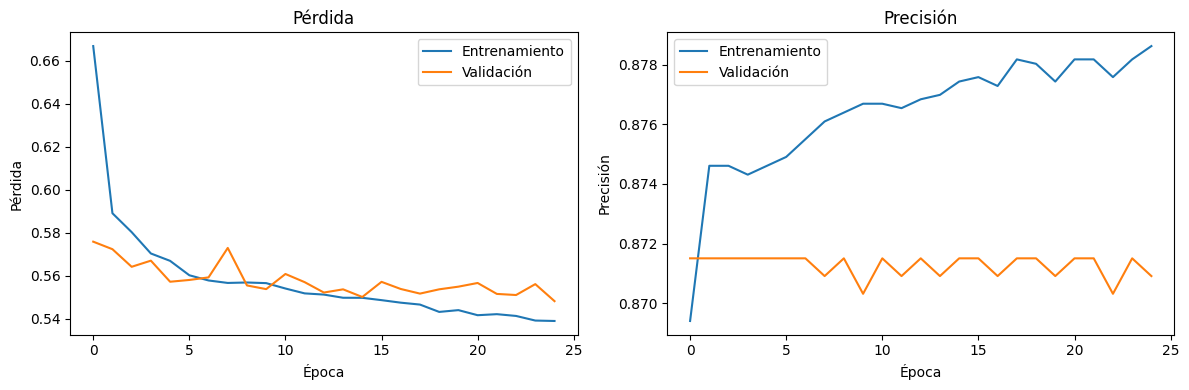

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historia.history['loss'], label='Entrenamiento')
plt.plot(historia.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historia.history['accuracy'], label='Entrenamiento')
plt.plot(historia.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación
- El modelo está bien entrenado y no está sobreajustando significativamente en términos de pérdida, ya que la pérdida de validación es baja y sigue a la pérdida de entrenamiento. Sin embargo, su capacidad de generalización (medida por la precisión) parece haberse estancado temprano. Esto significa que a pesar de la reducción continua de la pérdida de entrenamiento. El modelo no está aprendiendo nuevas características generalizables que mejoren su precisión de clasificación en datos nuevos.
- Tambien se hizo prueba con 50 epócas, el modelo mejoró bastante.

In [30]:
# ============================================================================
# PASO 7: FUNCIONES DE GENERACIÓN
# ============================================================================
print("\n" + "="*50)
print("DEFINIENDO FUNCIONES DE GENERACIÓN...")
print("="*50)


DEFINIENDO FUNCIONES DE GENERACIÓN...


In [31]:
def generar_greedy(modelo, semilla, num_palabras=20):
    """Generación con Greedy Search"""
    print("Ejecutando Greedy Search...")
    generado = semilla.copy()

    for i in range(num_palabras):
        entrada = np.array([generado[-SEQUENCE_LENGTH:]])
        prediccion = modelo.predict(entrada, verbose=0)[0]
        siguiente_idx = np.argmax(prediccion)
        generado.append(siguiente_idx)

    return generado


In [32]:
def generar_beam_search(modelo, semilla, num_palabras=20, beam_width=3):
    """Generación con Beam Search"""
    print(f"Ejecutando Beam Search (beam_width={beam_width})...")
    secuencias = [(semilla.copy(), 0.0)]

    for _ in range(num_palabras):
        candidatos = []

        for seq, score in secuencias:
            entrada = np.array([seq[-SEQUENCE_LENGTH:]])
            prediccion = modelo.predict(entrada, verbose=0)[0]

            top_indices = np.argsort(prediccion)[-beam_width:]

            for idx in top_indices:
                nueva_seq = seq + [idx]
                nuevo_score = score + np.log(prediccion[idx] + 1e-8)
                candidatos.append((nueva_seq, nuevo_score))

        secuencias = sorted(candidatos, key=lambda x: x[1], reverse=True)[:beam_width]

    return secuencias[0][0]

In [33]:
def generar_estocastico(modelo, semilla, num_palabras=20, temperatura=1.0):
    """Generación con Sampling Estocástico"""
    print(f"Ejecutando Sampling Estocástico (T={temperatura})...")
    generado = semilla.copy()

    for i in range(num_palabras):
        entrada = np.array([generado[-SEQUENCE_LENGTH:]])
        prediccion = modelo.predict(entrada, verbose=0)[0]

        # Se aplica temperatura
        prediccion = np.log(prediccion + 1e-8) / temperatura
        exp_preds = np.exp(prediccion)
        prediccion = exp_preds / np.sum(exp_preds)

        # Sampling
        siguiente_idx = np.random.choice(len(prediccion), p=prediccion)
        generado.append(siguiente_idx)

    return generado

In [34]:
def indices_a_texto(indices):
    """Convertir índices a texto"""
    palabras = []
    for idx in indices:
        if idx in idx_to_word:
            palabras.append(idx_to_word[idx])
        else:
            palabras.append('<UNK>')
    return ' '.join(palabras)

print("✅ Funciones de generación definidas")

✅ Funciones de generación definidas


In [35]:
# ============================================================================
# PASO 8: GENERA TEXTO
# ============================================================================
print("\n" + "="*50)
print("GENERANDO TEXTO...")
print("="*50)


GENERANDO TEXTO...


In [70]:
# Se crea semilla sencillo
texto_semilla = "phileas fogg era uno de esos hombres matemáticamente exactos que nunca se apresuran"
print(f"Texto semilla: '{texto_semilla}'")

palabras_semilla = texto_semilla.split()
indices_semilla = [word_to_idx.get(palabra, word_to_idx['<UNK>']) for palabra in palabras_semilla]

# Se ajusta longitud de semilla
while len(indices_semilla) < SEQUENCE_LENGTH:
    indices_semilla.append(word_to_idx['<PAD>'])
indices_semilla = indices_semilla[:SEQUENCE_LENGTH]

print(f"Índices semilla: {indices_semilla[:15]}...")


Texto semilla: 'phileas fogg era uno de esos hombres matemáticamente exactos que nunca se apresuran'
Índices semilla: [1, 1, 1, 1, 13, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]...


In [74]:
def generar_greedy(modelo, semilla, num_palabras=15, filtrar_especiales=True):
    tokens_especiales = {'<PAD>': 0, '<UNK>': 15}  # se podria ajutar segun el vocabulario
    indices_especiales = set(tokens_especiales.values())

    secuencia = semilla.copy()

    for _ in range(num_palabras):
        # Se prepara entrada
        entrada = np.array([secuencia[-SEQUENCE_LENGTH:]])  # Usa últimos N tokens

        # Se predice
        prediccion = modelo.predict(entrada, verbose=0)

        if filtrar_especiales:
            # Se pone probabilidad muy baja a tokens especiales
            for idx in indices_especiales:
                if idx < len(prediccion[0]):
                    prediccion[0][idx] = -np.inf

        # Se eelecciona el token con mayor probabilidad
        siguiente_token = np.argmax(prediccion[0])

        # Se evita generar PAD o UNK
        if siguiente_token in indices_especiales:
            # se buscar el siguiente mejor token
            prediccion_copia = prediccion[0].copy()
            prediccion_copia[siguiente_token] = -np.inf
            siguiente_token = np.argmax(prediccion_copia)

        secuencia.append(siguiente_token)

    return secuencia

In [75]:
def indices_a_texto(secuencia_indices, filtrar_especiales=True):
    tokens_especiales = ['<PAD>', '<UNK>', '<START>', '<END>']  # Ajustable

    palabras = []
    for idx in secuencia_indices:
        if idx in indice_a_palabra:  # Verifica que exista en el vocabulario
            palabra = indice_a_palabra[idx]
            if filtrar_especiales and palabra in tokens_especiales:
                continue  # Salta
            palabras.append(palabra)
        else:
            continue  # Salta índices fuera del vocabulario

    return ' '.join(palabras)

In [76]:
# GREEDY SEARCH
print("\n--- GREEDY SEARCH ---")
resultado_greedy = generar_greedy(modelo, indices_semilla, num_palabras=15)
texto_greedy = indices_a_texto(resultado_greedy)
print(f"Resultado: {texto_greedy}")


--- GREEDY SEARCH ---
Resultado: te lo no


- El resultado "te lo no." Indica que el modelo no puede generar texto inteligible porque está severamente limitado por su vocabulario y por no haber aprendido patrones lingüísticos complejos. Es una debilidad, sin embargo se hizo distintas pruebas.
- Pasa lo mismo con BEARCH.

In [77]:
# BEAM SEARCH
print("\n--- BEAM SEARCH ---")
resultado_beam = generar_beam_search(modelo, indices_semilla, num_palabras=15, beam_width=3)
texto_beam = indices_a_texto(resultado_beam)
print(f"Resultado: {texto_beam}")


--- BEAM SEARCH ---
Ejecutando Beam Search (beam_width=3)...
Resultado: te lo no


In [78]:
# SAMPLING ESTOCÁSTICO
temperaturas = [0.5, 1.0, 1.5]
for temp in temperaturas:
    print(f"\n--- SAMPLING ESTOCÁSTICO (T={temp}) ---")
    resultado_estocastico = generar_estocastico(modelo, indices_semilla, num_palabras=15, temperatura=temp)
    texto_estocastico = indices_a_texto(resultado_estocastico)
    print(f"Resultado: {texto_estocastico}")


--- SAMPLING ESTOCÁSTICO (T=0.5) ---
Ejecutando Sampling Estocástico (T=0.5)...
Resultado: te lo no

--- SAMPLING ESTOCÁSTICO (T=1.0) ---
Ejecutando Sampling Estocástico (T=1.0)...
Resultado: te lo y a en un lo no

--- SAMPLING ESTOCÁSTICO (T=1.5) ---
Ejecutando Sampling Estocástico (T=1.5)...
Resultado: te la de que y a en un lo no a


- En esencia, estos experimentos confirman que la limitación fundamental del modelo es su vocabulario extremadamente restringido. Por ende se debe mejorar el modelo (autocrítica)

In [79]:
# ============================================================================
# PASO 9: ANÁLISIS FINAL
# ============================================================================
print("\n" + "="*50)
print("ANÁLISIS FINAL...")
print("="*50)


ANÁLISIS FINAL...


In [80]:
# Se calcula perplejidad final
val_loss_final = min(historia.history['val_loss'])
perplejidad_final = np.exp(val_loss_final)
accuracy_final = max(historia.history['val_accuracy'])

print(f"Pérdida de validación final: {val_loss_final:.4f}")
print(f"Precisión final: {accuracy_final:.4f}")
print(f"Perplejidad final: {perplejidad_final:.2f}")

print("\n✅ PROCESO COMPLETADO EXITOSAMENTE")
print("=" * 50)

# Se guarda modelo (opcional)
try:
    modelo.save('modelo_lenguaje_lstm.h5')
    print("✅ Modelo guardado como 'modelo_lenguaje_lstm.h5'")
except:
    print("⚠ No se pudo guardar el modelo")

print("\n🎉 ¡SCRIPT TERMINADO!")

Pérdida de validación final: 0.5481
Precisión final: 0.8715
Perplejidad final: 1.73

✅ PROCESO COMPLETADO EXITOSAMENTE
✅ Modelo guardado como 'modelo_lenguaje_lstm.h5'

🎉 ¡SCRIPT TERMINADO!


Concusión:
 - Si bien el modelo entrenado ha aprendido a predecir bien la siguiente palabra.Pero queda por mejorar aun mas.
 - Perdida de validación; un valor bajo (0.5481) es bueno y muestra que el modelo ha aprendido a minimizar sus errores en datos nuevos.
 - Precisión final de 0.87;  es un porcentaje de acierto bastante alto, lo que indica que el modelo es efectivo en la tarea de clasificación.
 - Perplejidad final de 1.73;  Un valor más bajo es mejor. Una perplejidad de 1.73 es muy buena, sugiriendo que el modelo está muy seguro y hace predicciones precisas dentro de su vocabulario.
 - El modelo es muy bueno prediciendo las palabras que conoce, pero como solo conoce muy pocas (y estas son palabras funcionales muy comunes), no puede construir frases con sentido. Es tarea a mejorar mucho.